<a href="https://colab.research.google.com/github/chirontorudrapaul/AI-_ML/blob/main/heart_disease_using_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = pd.read_csv("/content/sample_data/heart.csv")

print("Shape:", df.shape)
print(df.info())
print(df.describe())

Shape: (1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
def build_model(optimizer):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='tanh'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
optimizers = {
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "Adagrad": Adagrad(learning_rate=0.01),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adam": Adam(learning_rate=0.001)
}

In [6]:
results = {}
histories = {}

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

for name, opt in optimizers.items():
    print(f"\n Training with {name}")

    model = build_model(opt)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = (model.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc
    histories[name] = history

    print(f"{name} Accuracy: {acc:.4f}")


🔹 Training with SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
SGD Accuracy: 1.0000

🔹 Training with Adagrad


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Adagrad Accuracy: 0.6927

🔹 Training with RMSprop


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RMSprop Accuracy: 0.7707

🔹 Training with Adam


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Adam Accuracy: 0.6341


In [8]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
results_df.to_csv("/content/sample_data/heart.csv")

print(results_df.sort_values(by="Accuracy", ascending=False))

         Accuracy
SGD      1.000000
RMSprop  0.770732
Adagrad  0.692683
Adam     0.634146


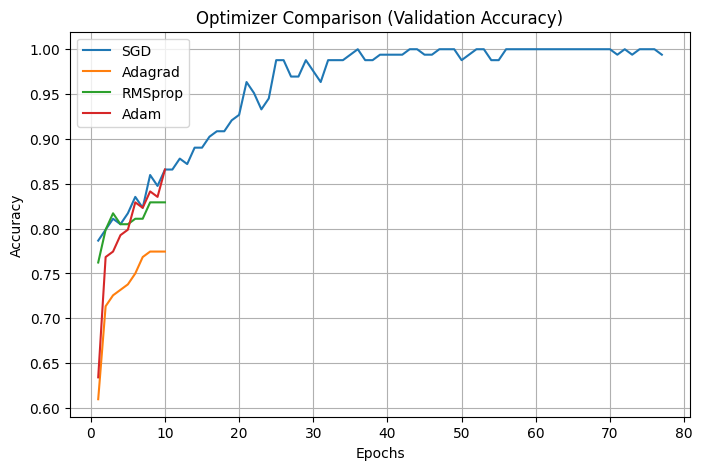

In [11]:
plt.figure(figsize=(8,5))

for name, history in histories.items():
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(val_acc) + 1)

    plt.plot(epochs, val_acc, label=name)

plt.title("Optimizer Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
best_optimizer_name = max(results, key=results.get)
print("Best Optimizer:", best_optimizer_name)

best_optimizer = optimizers[best_optimizer_name]

Best Optimizer: SGD


In [17]:
def get_fresh_optimizer(name):
    if name == "SGD":
        return SGD(learning_rate=0.01, momentum=0.9)
    elif name == "Adagrad":
        return Adagrad(learning_rate=0.01)
    elif name == "RMSprop":
        return RMSprop(learning_rate=0.001)
    elif name == "Adam":
        return Adam(learning_rate=0.001)

best_optimizer_fresh = get_fresh_optimizer(best_optimizer_name)

final_model = build_model(best_optimizer_fresh)

final_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6098 - loss: 0.6521 - val_accuracy: 0.7561 - val_loss: 0.5169
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8293 - loss: 0.4366 - val_accuracy: 0.7866 - val_loss: 0.4321
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8537 - loss: 0.3547 - val_accuracy: 0.8049 - val_loss: 0.4226
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8506 - loss: 0.3423 - val_accuracy: 0.8354 - val_loss: 0.4084
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8704 - loss: 0.3095 - val_accuracy: 0.8354 - val_loss: 0.4005
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8857 - loss: 0.2944 - val_accuracy: 0.8171 - val_loss: 0.3998
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8780 - loss: 0.2860 - val_accuracy: 0.8354 - val_loss: 0.3826
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8994 - loss: 0.2680 - val_accuracy: 0.8476 -

In [18]:
y_pred = (final_model.predict(X_test) > 0.5).astype(int)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))

print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Final Accuracy: 0.7853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.64      0.74       100
           1       0.73      0.92      0.82       105

    accuracy                           0.79       205
   macro avg       0.81      0.78      0.78       205
weighted avg       0.81      0.79      0.78       205


Confusion Matrix:
 [[64 36]
 [ 8 97]]


In [20]:
final_model.save("model.h5")
print("Model saved successfully")

Model saved successfully


In [23]:
loaded_model = tf.keras.models.load_model("model.h5")

sample = X_test[0].reshape(1, -1)

prob = loaded_model.predict(sample)[0][0]
prediction = int(prob > 0.5)

print("Probability:", prob)
print("Prediction:", prediction) #Prediction 0 means No Disease 1 means Disease

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Probability: 0.18330145
Prediction: 0
